Veri Ön İşleme (Preprocessing)

Bu notebook'ta EDA notebook'unda indirip kaydettiğimiz `data/AMZN.csv` dosyasını
model eğitimine hazır hale getiriyoruz.

**Adımlar:**
1. CSV'den veri yükleme
2. Kapanış fiyatını ayırma
3. MinMaxScaler ile normalizasyon
4. Sliding window (kayan pencere) ile sekans oluşturma
5. Train/test ayrımı (%80/%20)
6. PyTorch tensor dönüşümü
7. İşlenmiş verileri kaydetme

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import pickle
import os

from sklearn.preprocessing import MinMaxScaler

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

print("Kutuphaneler yuklendi")
print(f"PyTorch: {torch.__version__}")

Kutuphaneler yuklendi
PyTorch: 2.12.0+cpu


In [2]:
data = pd.read_csv("../data/AMZN.csv", index_col=0, parse_dates=True)

print(f"Veri yuklendi: {data.shape[0]} satir, {data.shape[1]} sutun")
print(f"Tarih araligi: {data.index[0].strftime('%Y-%m-%d')} - {data.index[-1].strftime('%Y-%m-%d')}")
print(f"Sutunlar: {list(data.columns)}")
data.head()

Veri yuklendi: 3642 satir, 5 sutun
Tarih araligi: 2012-01-03 - 2026-06-29
Sutunlar: ['Close', 'High', 'Low', 'Open', 'Volume']


,Close,High,Low,Open,Volume
Date,,,,,
2012-01-03,8.9515,8.9740,8.7775,8.7945,102216000
2012-01-04,8.8755,9.0250,8.8035,8.9605,84104000
2012-01-05,8.8805,8.9125,8.7025,8.7970,76182000
2012-01-06,9.1305,9.2325,8.8750,8.9035,140168000
2012-01-09,8.9280,9.2185,8.8500,9.1380,101138000


Price shape: (3642, 1)
Orjinal fiyat araligi: $8.80 - $274.99


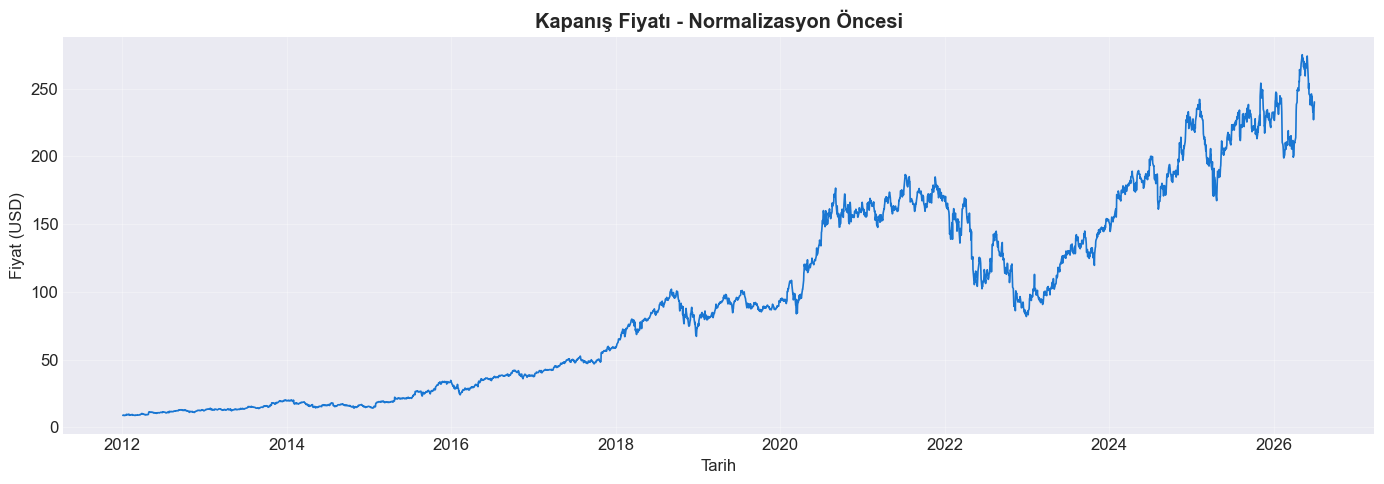

In [3]:
# Sadece kapanış fiyatını al
price = data[['Close']].copy()

print(f"Price shape: {price.shape}")
print(f"Orjinal fiyat araligi: ${price['Close'].min():.2f} - ${price['Close'].max():.2f}")

# Kapanış fiyatını görselleştir
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(price.index, price['Close'], color='#1976D2', linewidth=1.2)
ax.set_title('Kapanış Fiyatı - Normalizasyon Öncesi', fontweight='bold')
ax.set_xlabel('Tarih')
ax.set_ylabel('Fiyat (USD)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# MinMaxScaler oluştur: tüm değerleri [-1, 1] aralığına ölçekle
scaler = MinMaxScaler(feature_range=(-1, 1))

# fit_transform: önce veriye uyar (min/max öğrenir), sonra dönüştürür
price['Close'] = scaler.fit_transform(price['Close'].values.reshape(-1, 1))

print("Normalizasyon tamamlandi")
print(f"Yeni aralik: {price['Close'].min():.4f} ile {price['Close'].max():.4f}")
print(f"\nScaler bilgileri:")
print(f"  Orjinal min: ${scaler.data_min_[0]:.2f}")
print(f"  Orjinal max: ${scaler.data_max_[0]:.2f}")

Normalizasyon tamamlandi
Yeni aralik: -1.0000 ile 1.0000

Scaler bilgileri:
  Orjinal min: $8.80
  Orjinal max: $274.99


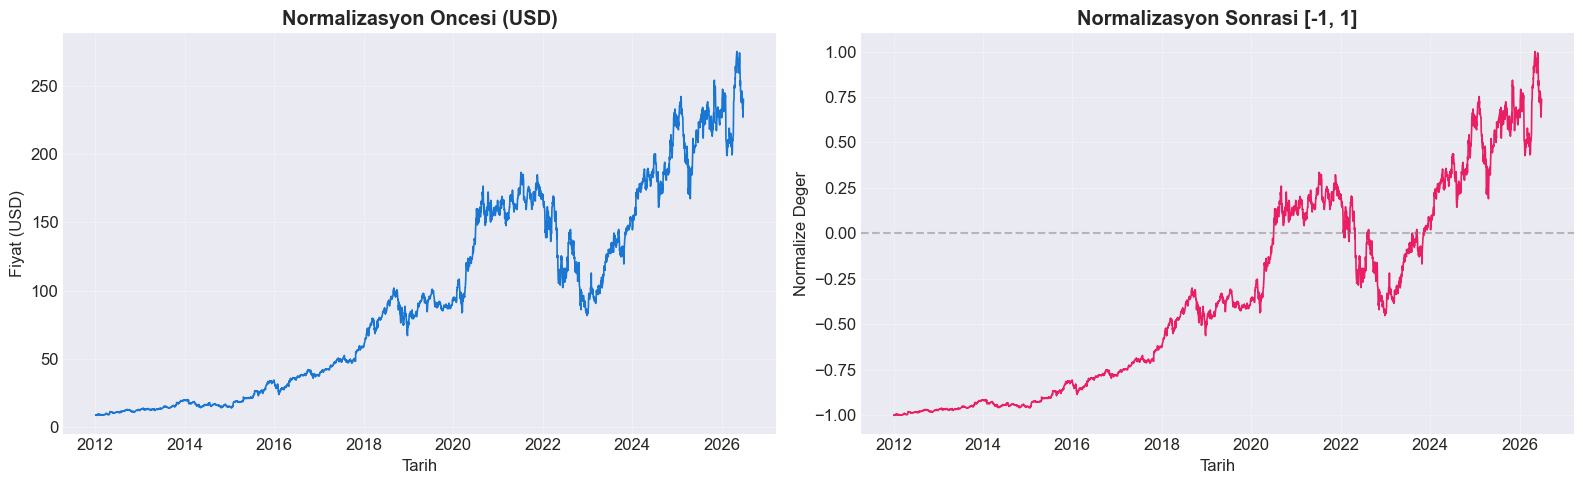

Grafik kaydedildi: results/normalizasyon_karsilastirma.png


In [5]:
# Normalizasyon öncesi ve sonrası karşılaştırma
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sol: orijinal fiyatlar
axes[0].plot(data.index, data['Close'], color='#1976D2', linewidth=1.2)
axes[0].set_title('Normalizasyon Oncesi (USD)', fontweight='bold')
axes[0].set_xlabel('Tarih')
axes[0].set_ylabel('Fiyat (USD)')
axes[0].grid(True, alpha=0.3)

# Sag: normalize edilmiş fiyatlar
axes[1].plot(price.index, price['Close'], color='#E91E63', linewidth=1.2)
axes[1].set_title('Normalizasyon Sonrasi [-1, 1]', fontweight='bold')
axes[1].set_xlabel('Tarih')
axes[1].set_ylabel('Normalize Deger')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/normalizasyon_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi: results/normalizasyon_karsilastirma.png")


Pencere her seferinde 1 gün kayar ve böylece binlerce eğitim örneği elde ederiz.

In [6]:
def split_data(stock, lookback):
    """
    Zaman serisi verisini kayan pencere yontemiyle egitim ve test
    setlerine ayirir.

    Parametreler:
        stock   : pd.DataFrame - normalize edilmis fiyat verisi
        lookback: int - pencere genisligi (kac gunluk veri kullanilacak)

    Dondurur:
        x_train, y_train, x_test, y_test - numpy dizileri
    """
    data_raw = stock.to_numpy()  # DataFrame'i numpy dizisine cevir
    data = []

    # Her olasi pencereyi olustur
    # ornek: 3642 satirlik veri, lookback=20 ise 3622 sekans olusur
    for index in range(len(data_raw) - lookback):
        data.append(data_raw[index: index + lookback])

    data = np.array(data)

    # Kronolojik train/test split: %80 egitim, %20 test
    # Zaman serilerinde rastgele karistirma yapilmaz!
    test_set_size = int(np.round(0.2 * data.shape[0]))
    train_set_size = data.shape[0] - test_set_size

    # Giris (x): pencerenin ilk (lookback-1) gunu
    # Hedef (y): pencerenin son gunu
    x_train = data[:train_set_size, :-1, :]   # Egitim girisleri
    y_train = data[:train_set_size, -1, :]     # Egitim hedefleri

    x_test = data[train_set_size:, :-1, :]     # Test girisleri
    y_test = data[train_set_size:, -1, :]      # Test hedefleri

    return x_train, y_train, x_test, y_test

print("split_data fonksiyonu tanimlandi")

split_data fonksiyonu tanimlandi


In [7]:
lookback = 20

x_train, y_train, x_test, y_test = split_data(price, lookback)

print("Veri boyutlari:")
print(f"  x_train : {x_train.shape}  (ornek, sekans_uzunlugu, ozellik)")
print(f"  y_train : {y_train.shape}  (ornek, ozellik)")
print(f"  x_test  : {x_test.shape}")
print(f"  y_test  : {y_test.shape}")
print(f"\nEgitim seti  : {x_train.shape[0]} ornek ({x_train.shape[0]/(x_train.shape[0]+x_test.shape[0])*100:.0f}%)")
print(f"Test seti    : {x_test.shape[0]} ornek ({x_test.shape[0]/(x_train.shape[0]+x_test.shape[0])*100:.0f}%)")
print(f"Sekans uzunl.: {x_train.shape[1]} gun")
print(f"Lookback     : {lookback}")

Veri boyutlari:
  x_train : (2898, 19, 1)  (ornek, sekans_uzunlugu, ozellik)
  y_train : (2898, 1)  (ornek, ozellik)
  x_test  : (724, 19, 1)
  y_test  : (724, 1)

Egitim seti  : 2898 ornek (80%)
Test seti    : 724 ornek (20%)
Sekans uzunl.: 19 gun
Lookback     : 20


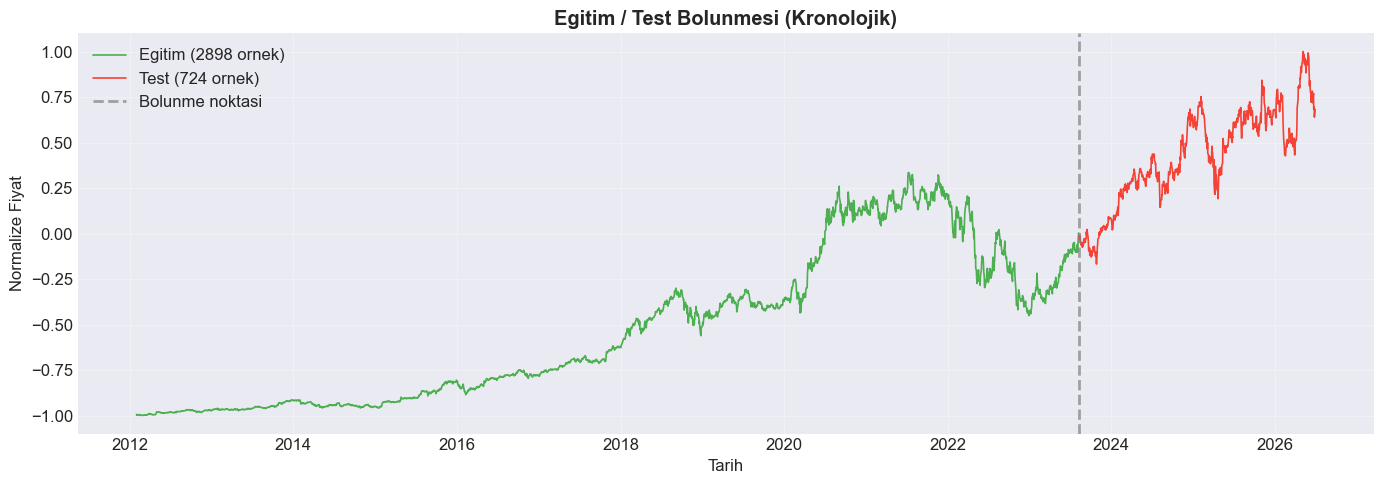

Egitim donemi : 2012-02-01 - 2023-08-08
Test donemi   : 2023-08-09 - 2026-06-29


In [8]:
# Egitim/test bolunme noktasini gorsellestir
split_point = x_train.shape[0]
dates = price.index[lookback:]  # ilk 'lookback' gun atlanir

fig, ax = plt.subplots(figsize=(14, 5))

# Normalize degerlerle ciz
train_dates = dates[:split_point]
test_dates = dates[split_point:]

ax.plot(train_dates, y_train, color='#4CAF50', linewidth=1.2, label=f'Egitim ({len(y_train)} ornek)')
ax.plot(test_dates, y_test, color='#F44336', linewidth=1.2, label=f'Test ({len(y_test)} ornek)')
ax.axvline(x=test_dates[0], color='gray', linestyle='--', linewidth=2, alpha=0.7, label='Bolunme noktasi')

ax.set_title('Egitim / Test Bolunmesi (Kronolojik)', fontweight='bold')
ax.set_xlabel('Tarih')
ax.set_ylabel('Normalize Fiyat')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

# Bolunme tarihini goster
print(f"Egitim donemi : {train_dates[0].strftime('%Y-%m-%d')} - {train_dates[-1].strftime('%Y-%m-%d')}")
print(f"Test donemi   : {test_dates[0].strftime('%Y-%m-%d')} - {test_dates[-1].strftime('%Y-%m-%d')}")

In [9]:
# Numpy array -> PyTorch tensor
x_train_tensor = torch.from_numpy(x_train).type(torch.Tensor)
x_test_tensor = torch.from_numpy(x_test).type(torch.Tensor)
y_train_tensor = torch.from_numpy(y_train).type(torch.Tensor)
y_test_tensor = torch.from_numpy(y_test).type(torch.Tensor)

print("Tensor donusumu tamamlandi")
print(f"  x_train_tensor : {x_train_tensor.shape}, dtype: {x_train_tensor.dtype}")
print(f"  y_train_tensor : {y_train_tensor.shape}, dtype: {y_train_tensor.dtype}")
print(f"  x_test_tensor  : {x_test_tensor.shape}")
print(f"  y_test_tensor  : {y_test_tensor.shape}")

Tensor donusumu tamamlandi
  x_train_tensor : torch.Size([2898, 19, 1]), dtype: torch.float32
  y_train_tensor : torch.Size([2898, 1]), dtype: torch.float32
  x_test_tensor  : torch.Size([724, 19, 1])
  y_test_tensor  : torch.Size([724, 1])


In [10]:
# Bir ornek sekansa bakalim: ilk egitim ornegi
print("Ornek sekans (ilk egitim ornegi):")
print(f"  Giris (x): {x_train_tensor[0].squeeze().numpy()[:5]}... ({x_train_tensor[0].shape[0]} deger)")
print(f"  Hedef (y): {y_train_tensor[0].item():.4f}")
print(f"\nYorum: Model, bu 19 gunluk fiyat dizisinden sonraki gunu tahmin etmeye calisacak.")

Ornek sekans (ilk egitim ornegi):
  Giris (x): [-0.99883544 -0.99940646 -0.9993689  -0.9974905  -0.999012  ]... (19 deger)
  Hedef (y): -0.9930

Yorum: Model, bu 19 gunluk fiyat dizisinden sonraki gunu tahmin etmeye calisacak.


In [11]:
# Tensorleri kaydet
torch.save({
    'x_train': x_train_tensor,
    'y_train': y_train_tensor,
    'x_test': x_test_tensor,
    'y_test': y_test_tensor,
}, '../data/tensors.pt')
print("Tensorler kaydedildi: data/tensors.pt")

# Scaler objesini kaydet (inverse_transform icin)
with open('../data/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler kaydedildi: data/scaler.pkl")

# Metadata kaydet (sonraki notebook icin)
metadata = {
    'lookback': lookback,
    'train_size': x_train.shape[0],
    'test_size': x_test.shape[0],
    'seq_length': x_train.shape[1],
    'train_dates': (train_dates[0].strftime('%Y-%m-%d'), train_dates[-1].strftime('%Y-%m-%d')),
    'test_dates': (test_dates[0].strftime('%Y-%m-%d'), test_dates[-1].strftime('%Y-%m-%d')),
}
with open('../data/metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)
print("Metadata kaydedildi: data/metadata.pkl")

# Dosya boyutlari
for fname in ['tensors.pt', 'scaler.pkl', 'metadata.pkl']:
    fpath = f'../data/{fname}'
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {fname}: {size_kb:.1f} KB")

Tensorler kaydedildi: data/tensors.pt
Scaler kaydedildi: data/scaler.pkl
Metadata kaydedildi: data/metadata.pkl
  tensors.pt: 285.2 KB
  scaler.pkl: 0.5 KB
  metadata.pkl: 0.2 KB


In [12]:
# Kayitli verileri yukle ve dogrula
loaded = torch.load('../data/tensors.pt', weights_only=True)
with open('../data/scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)
with open('../data/metadata.pkl', 'rb') as f:
    loaded_meta = pickle.load(f)

# Kontrol
assert loaded['x_train'].shape == x_train_tensor.shape, "x_train uyusmuyor!"
assert loaded['y_test'].shape == y_test_tensor.shape, "y_test uyusmuyor!"
assert torch.equal(loaded['x_train'], x_train_tensor), "x_train degerleri farkli!"
assert loaded_meta['lookback'] == lookback, "Lookback degeri farkli!"

print("Dogrulama basarili - tum veriler dogru kaydedilmis")
print(f"\nMetadata:")
for key, val in loaded_meta.items():
    print(f"  {key}: {val}")

Dogrulama basarili - tum veriler dogru kaydedilmis

Metadata:
  lookback: 20
  train_size: 2898
  test_size: 724
  seq_length: 19
  train_dates: ('2012-02-01', '2023-08-08')
  test_dates: ('2023-08-09', '2026-06-29')
